# Loading the Data from Kaggle

In [ ]:
# importing data from kaggle
import kagglehub
path = kagglehub.dataset_download("miadul/irrigation-water-requirement-prediction-dataset")

Using Colab cache for faster access to the 'irrigation-water-requirement-prediction-dataset' dataset.


In [ ]:
# Importing the necessary Python Libraries needed to conduct analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Importing other dependecies
import os

In [ ]:
# List the contents of the downloaded directory to find the CSV file
file_names = os.listdir(path)
csv_file = [f for f in file_names if f.endswith('.csv')][0] # there's one CSV file
full_csv_path = os.path.join(path, csv_file)
# Getting the data and putting it into a pd dataframe
df = pd.read_csv(full_csv_path)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

df = df.drop(columns=['Soil_Moisture'])

# 2. Basic Transformations (Unit Conversion)
# Convert km/h to m/s for the Penman-Monteith equation later
df['Wind_Speed_ms'] = df['Wind_Speed_kmh'] / 3.6
df = df.drop(columns=['Wind_Speed_kmh'])

# Separate features (X) and the temporary target (y)
X = df.drop(columns=['Irrigation_Need'])
y = df['Irrigation_Need']

# 3. Define Column Groups
ordinal_cols = ['Crop_Growth_Stage']
binary_cols = ['Mulching_Used']
nominal_cols = ['Soil_Type', 'Crop_Type', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']

# Updated numerical columns list (Soil_Moisture removed)
numeric_cols = [
    'Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Field_Area_hectare', 'Previous_Irrigation_mm', 'Wind_Speed_ms'
]

# Define the logical ordering for ordinal columns
stage_order = [['Sowing', 'Vegetative', 'Flowering', 'Harvest']]

# 4. Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Scale all numerical values to have a mean of 0 and variance of 1
        ('num', StandardScaler(), numeric_cols),

        # Encode the growth stage logically (0 to 3)
        ('ord', OrdinalEncoder(categories=stage_order), ordinal_cols),

        # Map 'No' to 0 and 'Yes' to 1
        ('bin', OrdinalEncoder(categories=[['No', 'Yes']]), binary_cols),

        # Create binary columns for categories. drop='first' avoids multicollinearity.
        ('nom', OneHotEncoder(drop='first', sparse_output=False), nominal_cols)
    ]
)

# 5. Fit and transform the data
X_processed_array = preprocessor.fit_transform(X)

# Optional: Convert back to a Pandas DataFrame to view it nicely
feature_names = preprocessor.get_feature_names_out()
X_processed = pd.DataFrame(X_processed_array, columns=feature_names)

print(f"Original shape: {X.shape}")
print(f"Processed shape: {X_processed.shape}")

Original shape: (10000, 18)
Processed shape: (10000, 32)


In [ ]:
def calculate_et0(row):
    """
    Calculates Reference Evapotranspiration (ET0) in mm/day using a
    simplified Penman-Monteith equation.
    """
    T = row['Temperature_C']
    RH = row['Humidity']
    u2 = row['Wind_Speed_ms']
    sunlight = row['Sunlight_Hours']

    # 1. Saturation Vapor Pressure (e_s) in kPa
    e_s = 0.6108 * np.exp((17.27 * T) / (T + 237.3))

    # 2. Actual Vapor Pressure (e_a) in kPa
    e_a = e_s * (RH / 100)

    # 3. Slope of Vapor Pressure Curve (Delta)
    delta = (4098 * e_s) / (T + 237.3)**2

    # 4. Psychrometric constant (gamma) - approx 0.066 at sea level
    gamma = 0.066

    # 5. Net Radiation (R_n)
    # Approximating solar radiation (MJ/m2/day) based on sunlight hours
    R_n = (sunlight / 12.0) * 15.0

    # Penman-Monteith Numerator terms
    radiation_term = 0.408 * delta * R_n
    wind_term = gamma * (900 / (T + 273)) * u2 * (e_s - e_a)

    # Denominator
    denominator = delta + gamma * (1 + 0.34 * u2)

    # Final ET0 (mm/day)
    et0 = (radiation_term + wind_term) / denominator
    return et0

# Standard FAO Crop Coefficients (Kc) for various growth stages
kc_map = {
    'Wheat': {'Sowing': 0.3, 'Vegetative': 1.15, 'Flowering': 1.15, 'Harvest': 0.25},
    'Maize': {'Sowing': 0.3, 'Vegetative': 1.20, 'Flowering': 1.20, 'Harvest': 0.35},
    'Cotton': {'Sowing': 0.35, 'Vegetative': 1.20, 'Flowering': 1.20, 'Harvest': 0.60},
    'Rice': {'Sowing': 1.05, 'Vegetative': 1.20, 'Flowering': 1.20, 'Harvest': 0.90},
    'Sugarcane': {'Sowing': 0.40, 'Vegetative': 1.25, 'Flowering': 1.25, 'Harvest': 0.75},
    'Potato': {'Sowing': 0.50, 'Vegetative': 1.15, 'Flowering': 1.15, 'Harvest': 0.75}
}

def get_crop_et(row):
    """Multiplies baseline ET0 by the specific Crop Coefficient"""
    et0 = row['ET_0_mm']
    crop = row['Crop_Type']
    stage = row['Crop_Growth_Stage']

    # Fetch the specific multiplier, default to 1.0 if not found
    kc = kc_map.get(crop, {}).get(stage, 1.0)
    return et0 * kc

# --- APPLYING THE PIPELINE TO YOUR DATAFRAME ---

# 1. Calculate base evaporation (mm/day)
df['ET_0_mm'] = df.apply(calculate_et0, axis=1)

# 2. Scale it to the specific crop and growth stage (mm/day)
df['Crop_Water_Need_mm'] = df.apply(get_crop_et, axis=1)

# 3. Calculate exact daily water volume required for the whole field (in Liters)
# 1 mm of water over 1 hectare = 10,000 Liters
df['Target_Water_Liters'] = df['Crop_Water_Need_mm'] * df['Field_Area_hectare'] * 10000

# 4. Clean up the dataframe by dropping the old categorical target
df = df.drop(columns=['Irrigation_Need', 'ET_0_mm', 'Crop_Water_Need_mm'])

print(df[['Crop_Type', 'Temperature_C', 'Humidity', 'Field_Area_hectare', 'Target_Water_Liters']].head())

  Crop_Type  Temperature_C  Humidity  Field_Area_hectare  Target_Water_Liters
0     Wheat          21.90     31.19                4.73         1.201856e+05
1     Maize          36.50     26.01               12.22         1.707511e+06
2    Cotton          41.83     76.41                5.52         1.948786e+05
3     Wheat          37.22     43.32                1.43         3.340001e+04
4    Cotton          22.38     86.44                2.52         3.233467e+04


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Define the NEW Features (X) and Target (y)
# Drop the target column to create our features matrix
X = df.drop(columns=['Target_Water_Liters'])
y = df['Target_Water_Liters'] # Our new continuous target

# 2. Prevent Data Leakage by splitting BEFORE preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit the preprocessor on the training data, transform the test data
# Note: 'preprocessor' should already be defined from your previous code block
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 4. Train the Random Forest Regressor
print("Training Random Forest Regressor...")
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train_processed, y_train)

# 5. Make Predictions
y_pred = rf_regressor.predict(X_test_processed)

# 6. Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL EVALUATION ---")
print(f"Mean Absolute Error (MAE): {mae:,.2f} Liters")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} Liters")
print(f"R-squared (R2): {r2:.4f}")

Training Random Forest Regressor...

--- MODEL EVALUATION ---
Mean Absolute Error (MAE): 32,162.42 Liters
Root Mean Squared Error (RMSE): 49,765.35 Liters
R-squared (R2): 0.9648


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming X_train_processed, X_test_processed, y_train, y_test are already created
# from the previous pipeline steps...

print("Training XGBoost Regressor...")

# 1. Initialize XGBoost
# We use standard baseline hyperparameters to compare it fairly against Random Forest
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,    # Step size shrinkage to prevent overfitting
    max_depth=6,          # Max depth of a tree
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

# 2. Train the Model
xgb_model.fit(X_train_processed, y_train)

# 3. Make Predictions
y_pred_xgb = xgb_model.predict(X_test_processed)

# 4. Evaluate the Model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- XGBOOST EVALUATION ---")
print(f"Mean Absolute Error (MAE): {mae_xgb:,.2f} Liters")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:,.2f} Liters")
print(f"R-squared (R2): {r2_xgb:.4f}")

Training XGBoost Regressor...

--- XGBOOST EVALUATION ---
Mean Absolute Error (MAE): 22,071.95 Liters
Root Mean Squared Error (RMSE): 34,300.57 Liters
R-squared (R2): 0.9833


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Setting up GridSearchCV for XGBoost...")

# 1. Define the hyperparameter grid
# We are testing 4 learning rates and 4 depths.
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 6, 8]
}

# 2. Initialize the base model
xgb_base = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 3. Setup GridSearchCV
# cv=5 means 5-fold cross-validation.
# It splits the training data 5 times to ensure the model isn't just getting lucky.
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1,  # Prints progress so you can watch it work
    n_jobs=-1   # Uses all available CPU cores in Colab
)

# 4. Fit the Grid Search
# CS note: This will train (4 * 4 * 5) = 80 distinct XGBoost models!
grid_search.fit(X_train_processed, y_train)

# 5. Extract and print the best results
print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")
best_xgb_model = grid_search.best_estimator_

# 6. Final Evaluation on the unseen Test Set
y_pred_optimized = best_xgb_model.predict(X_test_processed)

mae_opt = mean_absolute_error(y_test, y_pred_optimized)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
r2_opt = r2_score(y_test, y_pred_optimized)

print("\n--- OPTIMIZED XGBOOST EVALUATION ---")
print(f"Mean Absolute Error (MAE): {mae_opt:,.2f} Liters")
print(f"Root Mean Squared Error (RMSE): {rmse_opt:,.2f} Liters")
print(f"R-squared (R2): {r2_opt:.4f}")

Setting up GridSearchCV for XGBoost...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Hyperparameters Found: {'learning_rate': 0.1, 'max_depth': 6}

--- OPTIMIZED XGBOOST EVALUATION ---
Mean Absolute Error (MAE): 22,071.95 Liters
Root Mean Squared Error (RMSE): 34,300.57 Liters
R-squared (R2): 0.9833


/tmp/ipykernel_468/2843360325.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


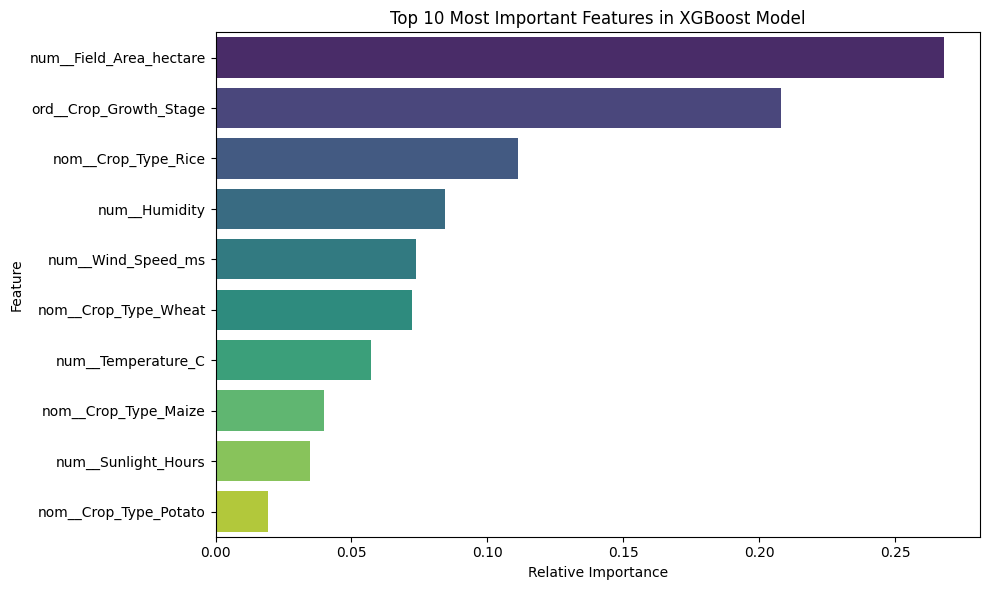

Top 5 Drivers of Irrigation Needs:
num__Field_Area_hectare: 26.78%
ord__Crop_Growth_Stage: 20.78%
nom__Crop_Type_Rice: 11.13%
num__Humidity: 8.44%
num__Wind_Speed_ms: 7.38%


In [ ]:
# 1. Get the feature importances from the optimized model
importances = best_xgb_model.feature_importances_

# 2. Get the names of the columns (features) we trained on
# feature_names was generated earlier when we created X_processed
feature_names = preprocessor.get_feature_names_out()

# 3. Create a DataFrame to sort and plot easily
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Top 10 Most Important Features in XGBoost Model")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 5. Print the exact percentages for the top 5
print("Top 5 Drivers of Irrigation Needs:")
for index, row in importance_df.head(5).iterrows():
    print(f"{row['Feature']}: {row['Importance'] * 100:.2f}%")

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, median_absolute_error, max_error

# 1. Calculate Additional Metrics
mape_opt = mean_absolute_percentage_error(y_test, y_pred_optimized)
medae_opt = median_absolute_error(y_test, y_pred_optimized)
max_err_opt = max_error(y_test, y_pred_optimized)

print("\n--- ADDITIONAL REGRESSION METRICS ---")
# Multiply MAPE by 100 to format it as a percentage
print(f"Mean Absolute Percentage Error (MAPE): {mape_opt * 100:.2f}%")
print(f"Median Absolute Error (MedAE): {medae_opt:,.2f} Liters")
print(f"Max Error (Worst Prediction): {max_err_opt:,.2f} Liters")


--- ADDITIONAL REGRESSION METRICS ---
Mean Absolute Percentage Error (MAPE): 12.50%
Median Absolute Error (MedAE): 13,411.66 Liters
Max Error (Worst Prediction): 300,531.54 Liters


In [ ]:
import joblib

# Define the filenames for the model and the preprocessor
model_filename = 'optimized_xgb_model.joblib'
preprocessor_filename = 'preprocessor.joblib'

# Save the optimized XGBoost model
joblib.dump(best_xgb_model, model_filename)

# Save the preprocessor (ColumnTransformer)
# This allows you to apply the same transformations to new data during inference
joblib.dump(preprocessor, preprocessor_filename)

print(f"Model saved successfully as {model_filename}")
print(f"Preprocessor saved successfully as {preprocessor_filename}")

Model saved successfully as optimized_xgb_model.joblib
Preprocessor saved successfully as preprocessor.joblib
